In [1]:
import os

# Change cwd to the notebook's directory for VS Code 
try:
    notebook_path = globals()['__vsc_ipynb_file__']
    notebook_dir = os.path.dirname(notebook_path)
    os.chdir(notebook_dir)
    print(f"Changed directory to: {notebook_dir}")
except:
    print("Could not find notebook path. Running from:", os.getcwd())

Changed directory to: /lustre/groups/imm01/workspace/yang/DextraDemixer/experiments/Ioanna_data


In [2]:
import sys 

sys.path.append("../../")

import numpyro as npy
import numpy as np
import pandas as pd
import scanpy as sc
import scirpy as ir
import itertools as itr
import seaborn as sns
import resource

from matplotlib import pyplot as plt, cm as mpl_cm
import matplotlib as mpl
from cycler import cycler
from statsmodels.stats.multitest import fdrcorrection
from sklearn.metrics import classification_report, average_precision_score, precision_score, recall_score, accuracy_score, confusion_matrix, f1_score, roc_auc_score, matthews_corrcoef

import mudata as md
from mudata import MuData, AnnData
import muon as mu
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="mudata")

from IPython.display import Markdown

from dextrademixer.model import DextraDemixer, BEAMT #, ITRAP,  ICON
from dextrademixer.utils import calculate_metrics
#from dextrademixer.model.ITRAP import ITRAP

pd.set_option('display.max_columns', 200)
# mu.set_options(pull_on_update=True) 

/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# Helper function:
dex_map ={"HLA-A*0201": "DexA", "HLA-C*0702":"DexC", "HLA-B*0801":"DexN", "HLA-B*0702":"DexB"}


def run_BEAMT(mdat,
              y_true,
              df,
              pmhc_key="HLA-A*0201",
              gex_key="rio",
              ir_key="airr",
              neg_ctrl_key="HLA-B*0801",
              threshold=0.5,
              target_fdr=None):

    model_config = f"beamt"
    #config = f"Data_{data_config}_model_{model_config}"
    mdat = mdat[~np.isnan(y_true),:]
    
    mixer = BEAMT()
    mixer.preprocess_model_data(mdat, pmhc_key=pmhc_key, gex_key=gex_key, neg_ctrl_key=neg_ctrl_key, ir_key=ir_key)

    mixer.fit()
    p_pred, assignment = mixer.predict_posterior_class(target_fdr=target_fdr, threshold=threshold)
    p_pred = p_pred.__array__()
    assignment = assignment.__array__()
    
    df.loc[~np.isnan(y_true),f"{dex_map.get(pmhc_key, 'DexB')}_ppred_"+model_config] = p_pred
    df.loc[~np.isnan(y_true),f"{dex_map.get(pmhc_key, 'DexB')}_assignment_"+model_config] = assignment
        
    metrics = eval_results(y_true[~np.isnan(y_true)], assignment, p_pred, None)
    # print(f"{setting} BEAMT F1 {metrics['f1']:.3f}, Precision {metrics['precision']:.3f}, Recall {metrics['recall']:.3f} FDR {metrics['fdr']:.3f} MCC {metrics['mcc']:.3f}\n")
    return metrics


def eval_results(y_true, y_pred, p_pred, config):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr = tp / (tp + fn)
    fdr = fp / (tp + fp)

    mask = y_true.notna().to_numpy()
    
    results = pd.Series()
    results['roc_auc'] = roc_auc_score(y_true[mask].astype(int), p_pred[mask])
    results['pr_auc'] = average_precision_score(y_true[mask].astype(int), p_pred[mask])
    results['f1'] = f1_score(y_true[mask].astype(int), y_pred[mask])
    results['precision'] = precision_score(y_true[mask].astype(int), y_pred[mask])
    results['recall'] = recall_score(y_true[mask].astype(int), y_pred[mask])
    results['accuracy'] = accuracy_score(y_true[mask].astype(int), y_pred[mask])
    results['mcc'] = matthews_corrcoef(y_true[mask].astype(int), y_pred[mask])
    results['fdr'] = fdr
        
    #results.to_csv(config+"_performance.csv")
    return results


In [5]:
mdata = mu.read_h5mu("./mudata_scanpy_new.h5mu")
mdata

/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/anndata/utils.py:362: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


MuData object with n_obs × n_vars = 9229 × 20154
  uns:	'Cell_colors', 'Dex_colors', 'Sample_colors', 'cartridge_colors', 'cluster_colors', 'pca'
  obsm:	'AB', 'HTO', 'HTOflex', 'RNA', 'RiO', 'RiO_bg', 'X_pca', 'X_umap', 'X_wnn.umap', 'wnn.umap'
  varm:	'AB', 'HTO', 'HTOflex', 'PCs', 'RNA', 'RiO', 'RiO_bg'
  obsp:	'wknn', 'wsnn'
  7 modalities
    airr:	2835 x 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'cluster', 'Dex', 'clone_id', 'clone_id_size', 'antigen.species', 'antigen.gene'
      uns:	'chain_indices', 'clone_id', 'clonotype_network', 'ir_dist_VDJDB_aa_identity', 'ir_dist_nt_identity', 'ir_query_VDJDB_aa_identity', 'scirpy_version'
      obsm:	'X_clonotype_network', 'airr', 'chain_indices'
    rna:	9229 x 20107
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_HTOflex', 'nFeature_HTOflex', 'nReads_ALL', 'nReads_RNA', 'percent.mito', 'meanCount_RNA', 'meanCount_HTO', 'meanCount_HTOflex', 'HTOflex_maxID', 'HTOflex_secondID', 'HTOflex_margin', 'HTOflex_classification', 'HTOflex_classification.global', 'hash.ID', 'hash.ID.flex', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'tag.no', 'Sample', 'SpikeIn.pct', 'Background', 'Background.Donor', 'Background.pct', 'flex.tag.no', 'Cell', 'Type', 'Donor', 'Donor.long', 'Origin', 'Specificity', 'peptide.stim', 'CMV.peptide', 'Peptide.Seq', 'HLA.A.02.01', 'HLA.B.07.02', 'HLA.C.07.02', 'nCount_AB', 'nFeature_AB', 'nCount_RiO', 'nFeature_RiO', 'cartridge', 'S.Score', 'G2M.Score', 'Phase', 'RNA_snn_res.0.5', 'seurat_clusters', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'AB.weight', 'wsnn_res.0.5', 'wsnn_res.0.5_anno', 'wsnn_res.0.5_old', 'wsnn_res.0.52', 'wsnn_res.0.52_anno', 'nCount_RiO_bg', 'nFeature_RiO_bg', 'cell_id', 'DexA', 'DexB', 'DexC', 'Dex', 'flex_tag_label', 'cluster', 'category'
      var:	'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'highly_variable'
      uns:	'pca'
      obsm:	'X_pca', 'wnn.umap'
      varm:	'PCs'
      layers:	'counts', 'data'
    ab:	9229 x 31
      var:	'highly_variable'
      uns:	'apca'
      obsm:	'X_apca'
      varm:	'apca'
      layers:	'counts', 'data'
    rio:	9229 x 4
      layers:	'counts'
    rio_bg:	9229 x 3
      layers:	'counts', 'data'
    hto:	9229 x 4
      layers:	'counts'
    hto_flex:	9229 x 5
      layers:	'counts'

In [6]:
# These are the four samples: Donor 1 & 2, each with 5 or 50% theoretical spikein over all 3 clones (detected is less)
mdata.obs[['rna:Sample', ]].value_counts(dropna=False)

rna:Sample
05-95-D2      2754
05-95-D1      2348
50-50-D1      2161
50-50-D2      1966
Name: count, dtype: int64

In [7]:
# Spike-in clones are True, HLA-mismatched BG are False (BG_D1 False for NLV, BG_D2 False for CRV)
# HLA-matched BG are nan because we don't know if there are some clonotypes that may bind
mdata.obs['NLV_true'] = np.where(mdata.obs["rna:flex_tag_label"] == 'NLV_Clone', 1, np.where(mdata.obs["rna:flex_tag_label"] =='BG_D1', np.nan, 0))
mdata.obs['CRV_true'] = np.where(mdata.obs["rna:flex_tag_label"] == 'CRV_Clone', 1, np.where(mdata.obs["rna:flex_tag_label"] == 'BG_D2', np.nan, 0))
mdata.obs['TPR_true'] = np.where((mdata.obs["rna:flex_tag_label"] == 'TPR_enriched') & (mdata.obs['rna:wsnn_res.0.5_anno'] == 'TPR_enriched_CD8_other'), 1, np.where(mdata.obs["rna:flex_tag_label"] == 'BG_D2', np.nan, 0))

HLA-A*0201 05-95-D2 clone_avail_only=True Mean increase: 36.0 ratio 0.0084 N=835
HLA-A*0201 05-95-D2 clone_avail_only=False Mean increase: 19.8 ratio 0.0087 N=2752


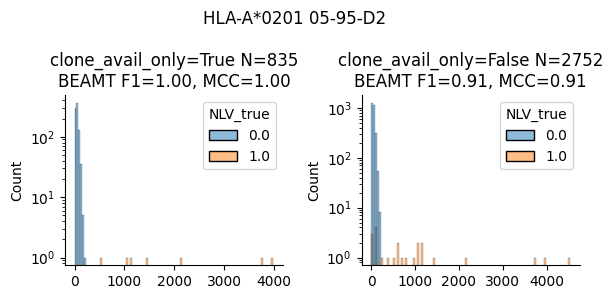

HLA-A*0201 50-50-D2 clone_avail_only=True Mean increase: 23.2 ratio 0.0494 N=587
HLA-A*0201 50-50-D2 clone_avail_only=False Mean increase: 18.5 ratio 0.0407 N=1966


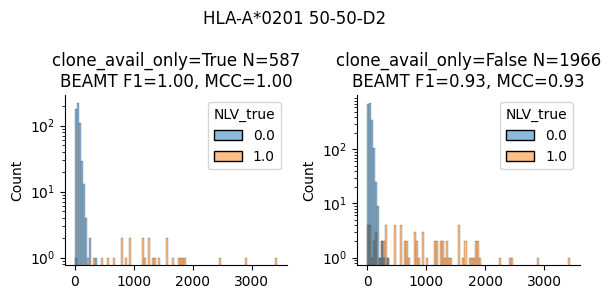

HLA-C*0702 05-95-D1 clone_avail_only=True Mean increase: 9.8 ratio 0.0042 N=709
HLA-C*0702 05-95-D1 clone_avail_only=False Mean increase: 13.4 ratio 0.0047 N=2348


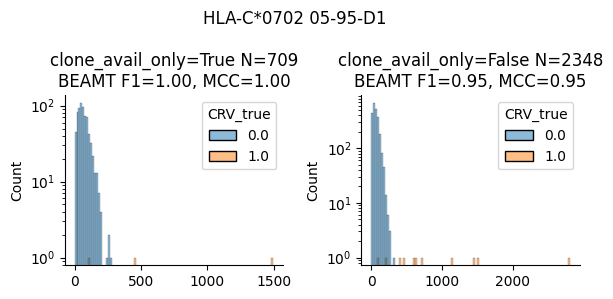

HLA-C*0702 50-50-D1 clone_avail_only=True Mean increase: 14.9 ratio 0.0697 N=703
HLA-C*0702 50-50-D1 clone_avail_only=False Mean increase: 13.3 ratio 0.0569 N=2161


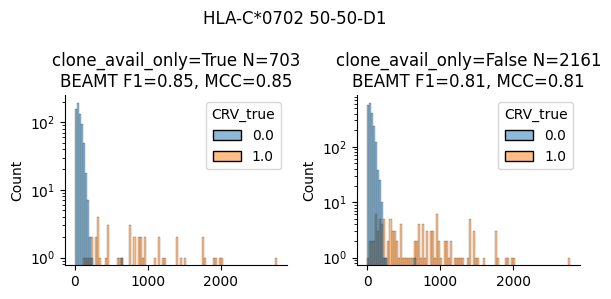

In [8]:
# Visualize 
true_labels = {"HLA-A*0201":"NLV_true", "HLA-C*0702":"CRV_true", "HLA-B*0702":"TPR_true"}

for dex_key, sample in [('HLA-A*0201', '05-95-D2'), ('HLA-A*0201', '50-50-D2'), ('HLA-C*0702', '05-95-D1'), ('HLA-C*0702', '50-50-D1')]:
    plt.figure(figsize=(6, 3))
    i = 0
    for tcr_info_sequenced_only in [True, False]:
        i += 1
        plt.subplot(1, 2, i)
        mdata_sample = mdata[mdata.obs[f'rna:Sample'] == sample].copy()
        if tcr_info_sequenced_only:
            mdata_sample = mdata_sample[mdata_sample['airr'].obs_names]
        mdata_sample = mdata_sample[mdata_sample.obs[true_labels[dex_key]].notna()].copy()
        sns.histplot(x=mdata_sample['rio'][:, dex_key].X.toarray()[:, 0], hue=mdata_sample.obs[true_labels[dex_key]], bins=100)
        n_samples = mdata_sample.shape[0]
        plt.yscale('log')
        sns.despine()

        # Train models
        y_true = mdata_sample.obs[true_labels[dex_key]]
        # mdata_tmp = mdata_sample[~np.isnan(y_true),:].copy()
        df = pd.DataFrame({"barcode":mdata_sample.obs_names, "NLV_true":mdata_sample.obs.NLV_true, "CRV_true":mdata_sample.obs.CRV_true, "TPR_true":mdata_sample.obs.TPR_true})

        # # BEAMT
        setting = f'{dex_key},{sample},{tcr_info_sequenced_only}'
        # result = {'dex_key': dex_key, 'model_config': 'BEAMT', 'sample': sample, 'tcr_info_sequenced_only': tcr_info_sequenced_only, 'setting': setting, }
        result_ = run_BEAMT(mdata_sample, y_true, df, pmhc_key=dex_key, gex_key="rio", ir_key="airr", neg_ctrl_key="HLA-B*0801", threshold=0.5, target_fdr=None)
        
        pos = mdata_sample[y_true.astype(bool)]
        neg = mdata_sample[~y_true.astype(bool)]
        pos_mean = pos['rio'][:, dex_key].X.toarray().mean()
        neg_mean = neg['rio'][:, dex_key].X.toarray().mean()
        print(f'{dex_key} {sample} clone_avail_only={tcr_info_sequenced_only} Mean increase: {(pos_mean / neg_mean):.1f} ratio {pos.shape[0]/n_samples:.4f} N={n_samples}')

        plt.title(f'clone_avail_only={tcr_info_sequenced_only} N={n_samples}\nBEAMT F1={result_["f1"]:.2f}, MCC={result_["mcc"]:.2f}')
        
    plt.suptitle(f'{dex_key} {sample}')
    plt.tight_layout()
    plt.show()


In [9]:
# BEAMT

results = []
for dex_key, sample in [('HLA-A*0201', '05-95-D2'), ('HLA-A*0201', '50-50-D2'), ('HLA-C*0702', '05-95-D1'), ('HLA-C*0702', '50-50-D1')]:
    for tcr_info_sequenced_only in [True, False]:
        mdata_sample = mdata[mdata.obs[f'rna:Sample'] == sample]
        if tcr_info_sequenced_only:
            mdata_sample = mdata_sample[mdata_sample['airr'].obs_names]

        df = pd.DataFrame({"barcode":mdata_sample.obs_names, 
                           "NLV_true":mdata_sample.obs.NLV_true,
                           "CRV_true":mdata_sample.obs.CRV_true,
                           "TPR_true":mdata_sample.obs.TPR_true})

        true_labels = {"HLA-A*0201":"NLV_true", "HLA-C*0702":"CRV_true", "HLA-B*0702":"TPR_true"}

        # Train models
        mask = mdata_sample.obs[true_labels[dex_key]]
        mdata_tmp = mdata_sample[~np.isnan(mask),:].copy()
        y_true = mdata_tmp.obs[true_labels[dex_key]]
        
        # BEAMT
        model_config = f"beamt"
        setting = f'{dex_map[dex_key]},{sample},{tcr_info_sequenced_only}'
        result = {'dex_key': dex_key, 'model_config': 'BEAMT', 'sample': sample, 'tcr_info_sequenced_only': tcr_info_sequenced_only, 'setting': setting, }
        mixer = BEAMT()
        mixer.preprocess_model_data(mdata_tmp, pmhc_key=dex_key, gex_key='rio', neg_ctrl_key='HLA-B*0801', ir_key='airr')    
        
        mixer.fit()
        p_pred, assignment = mixer.predict_posterior_class(target_fdr=None, threshold=0.5)
        p_pred = p_pred.__array__()
        assignment = assignment.__array__()
        metrics = eval_results(y_true, assignment, p_pred, None)
        result.update(metrics)
        results.append(result)

results_beamt = results.copy()
results_beamt = pd.DataFrame(results_beamt)
results_beamt

,dex_key,model_config,sample,tcr_info_sequenced_only,setting,roc_auc,pr_auc,f1,precision,recall,accuracy,mcc,fdr
0,HLA-A*0201,BEAMT,05-95-D2,True,"DexA,05-95-D2,True",1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
1,HLA-A*0201,BEAMT,05-95-D2,False,"DexA,05-95-D2,False",0.999465,0.968339,0.913043,0.954545,0.875000,0.998547,0.913190,0.045455
2,HLA-A*0201,BEAMT,50-50-D2,True,"DexA,50-50-D2,True",1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
3,HLA-A*0201,BEAMT,50-50-D2,False,"DexA,50-50-D2,False",0.989346,0.957041,0.928105,0.972603,0.887500,0.994405,0.926250,0.027397
4,HLA-C*0702,BEAMT,05-95-D1,True,"DexC,05-95-D1,True",1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
5,HLA-C*0702,BEAMT,05-95-D1,False,"DexC,05-95-D1,False",0.999844,0.975758,0.952381,1.000000,0.909091,0.999574,0.953259,0.000000
6,HLA-C*0702,BEAMT,50-50-D1,True,"DexC,50-50-D1,True",0.994976,0.963754,0.847059,1.000000,0.734694,0.981508,0.848749,0.000000
7,HLA-C*0702,BEAMT,50-50-D1,False,"DexC,50-50-D1,False",0.975540,0.899232,0.811321,0.966292,0.699187,0.981490,0.813472,0.033708


# DextraDemixer

In [10]:
def plot_confusion_hist(df, assignment, title=''):
    confusion_df = pd.DataFrame({ 'x_umi': df['x_umi'], 'True': df['y_true'], 'Predicted': assignment })
    conditions = [ (confusion_df['True'] == 0.0) & (confusion_df['Predicted'] == 0.0), (confusion_df['True'] == 1.0) & (confusion_df['Predicted'] == 1.0), (confusion_df['True'] == 0.0) & (confusion_df['Predicted'] == 1.0), (confusion_df['True'] == 1.0) & (confusion_df['Predicted'] == 0.0) ]

    choices = [ 'True Negative', 'True Positive', 'False Positive', 'False Negative' ]
    confusion_df['Outcome'] = np.select(conditions, choices, default='Unknown')

    plt.figure(figsize=(4, 3))
    custom_palette = { 'True Negative': '#8DB4E2', 'True Positive': '#1F4E79', 'False Positive': '#C00000', 'False Negative': '#FFC000' }
    ax = sns.histplot( data=confusion_df, x='x_umi', hue='Outcome', palette=custom_palette, hue_order=choices, bins=100, multiple="stack", 
                edgecolor="white", 
                linewidth=0.5 )
    sns.move_legend(ax, 'upper left', bbox_to_anchor=(0.5, 1), frameon=False, ncols=1)
    plt.yscale('log')
    sns.despine()
    plt.title(title)
    plt.show()

In [11]:
seed = 42
alpha_offset = 5
hyperprior = 1.0
use_size_factor = True
outlier_threshold = None
results = []
pred_dfs = []


if os.path.exists('results.csv'):
    pred_dfs = pd.read_csv('pred_df.csv')
    results_df = pd.read_csv('results.csv')

else:
    for dex_key, sample in [('HLA-A*0201', '05-95-D2'), ('HLA-A*0201', '50-50-D2'), ('HLA-C*0702', '05-95-D1'), ('HLA-C*0702', '50-50-D1')]:
        for tcr_info_sequenced_only in [False, True]:
            mdata_sample = mdata[mdata.obs[f'rna:Sample'] == sample]
            if tcr_info_sequenced_only:
                mdata_sample = mdata_sample[mdata_sample['airr'].obs_names]
        
            true_labels = {"HLA-A*0201":"NLV_true", "HLA-C*0702":"CRV_true", "HLA-B*0702":"TPR_true"}
        
            # Train models
            mask = mdata_sample.obs[true_labels[dex_key]]
            mdata_sample = mdata_sample[~np.isnan(mask),:].copy()
            y_true = mdata_sample.obs[true_labels[dex_key]]
        
            setting = f'{dex_map[dex_key]},{sample},{tcr_info_sequenced_only}'
            pred_df = mdata_sample.obs.copy()
            pred_df['setting'] = setting
            pred_df['x_umi'] = mdata_sample['rio'][:, dex_key].X.toarray()[:, 0]
            pred_df['y_true'] = y_true

            for neg_ctrl_key in [None, 'HLA-B*0801']:
                model = DextraDemixer(model_type='mixturemodelkmeans', mode='I', alpha_model='overdispersion',
                                    model_config={"overdispersion_scale_prior": hyperprior, "alpha_offset": alpha_offset})
                model.preprocess_model_data(mdata_sample, pmhc_key=dex_key, gex_key="rio", neg_ctrl_key=neg_ctrl_key,
                                            ir_clone_key=None, outlier_threshold=outlier_threshold, use_size_factor=use_size_factor)
                opt_params = {"maxiter": 1000, "nof_inits": 10, "adam": {"init_value": 3e-1, "end_value": 3e-3, "decay_rate": 0.995, "transition_steps": 1}, }
            
                model.fit_svi(guide='normal', svi_config=opt_params, nof_inits=opt_params["nof_inits"], rng_key=42, y_true=None)
                samples = model.get_posterior_samples()
                for clone_mean in ['clone_id', False]:
                    # Fill nan clones with a unique clone id
                    if clone_mean:
                        clone_id = mdata_sample.obs[f'airr:{clone_mean}'].copy()
                        clone_id = clone_id.astype(float)
                        max_id = clone_id.max()
                        num_nans = clone_id.isna().sum()
                        clone_id[clone_id.isna()] = np.arange(max_id, max_id+num_nans)
                    else:
                        clone_id = None

                    model_config = f"{'no-neg' if neg_ctrl_key is None else 'neg'},{clone_mean if clone_mean else 'no-clone'}"
            
                    p_pred, assignment = model.predict_posterior_class(threshold=0.5, clonotype_mean_p=bool(clone_mean), clone_id=clone_id)
                    pred_df[f'p_pred_{model_config}'] = p_pred
                    pred_df[f'assignment_{model_config}'] = assignment

                    metrics = eval_results(y_true, assignment, p_pred, None)
                    # model.plot_results(assignment, p_pred, y_true[~np.isnan(y_true)], seed,
                    #                 f"{setting} {model_config}", save_dir='figs', show=False)
            
                    result = {'sample': sample, 'tcr_info_sequenced_only': tcr_info_sequenced_only, 'setting': setting, 
                            'dex_key': dex_key, 'clone_mean': clone_mean, 'neg_ctrl_key': neg_ctrl_key, 'model_config': model_config, 
                            'hyperprior': hyperprior, 'alpha_offset': alpha_offset,
                            'outlier_threshold': outlier_threshold,
                            'use_size_factor': use_size_factor}

                    print(f"{setting} {model_config} F1 {metrics['f1']:.3f}, Precision {metrics['precision']:.3f}, Recall {metrics['recall']:.3f} FDR {metrics['fdr']:.3f} MCC {metrics['mcc']:.3f}\n")
                    result.update(metrics)
                    samples_clean = {k: np.array(v) for k, v in samples.items()}
                    result.update(samples_clean)
                    results.append(result)
            
            pred_dfs.append(pred_df)

    pred_dfs = pd.concat(pred_dfs)
    pred_dfs.to_csv('pred_df.csv')
    results_df = pd.DataFrame(results)
    results_df.to_csv('results.csv')

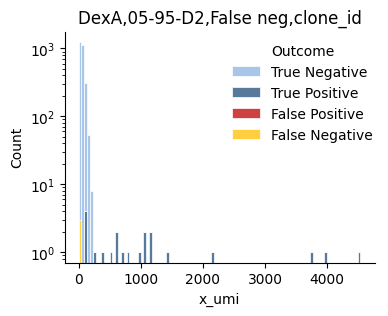

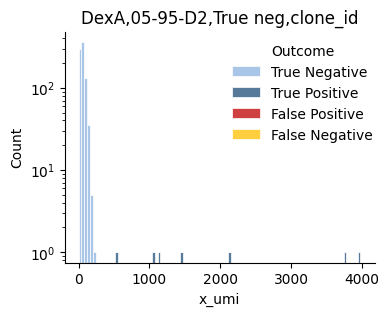

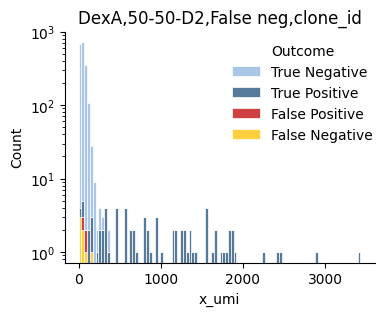

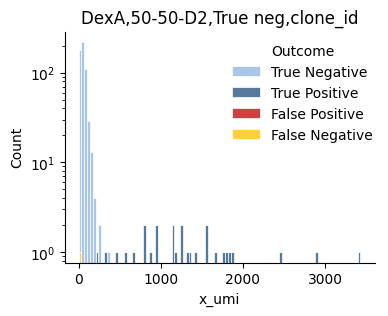

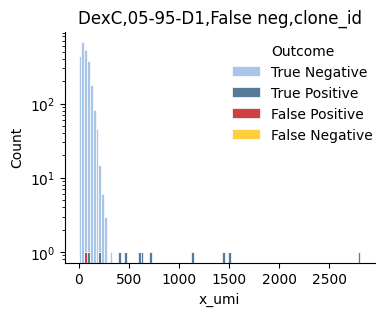

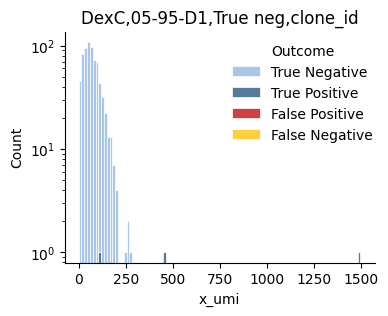

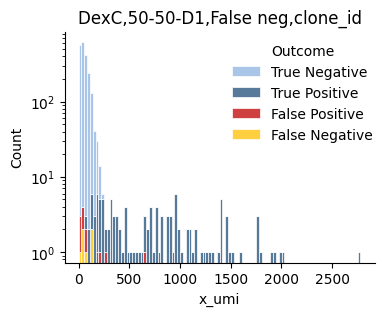

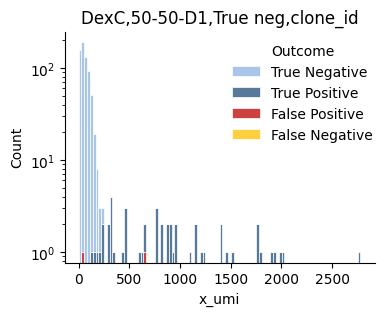

In [12]:
for setting in pred_dfs['setting'].unique():
    for model_config in ['neg,clone_id',]:# 'no-neg,clone_id', 'neg,no-clone', 'no-neg,no-clone']:
        plot_confusion_hist(pred_dfs[pred_dfs['setting'] == setting], pred_dfs[pred_dfs['setting'] == setting][f'assignment_{model_config}'], title=setting + ' ' + model_config)


In [13]:
results_merged = pd.concat([results_df, results_beamt])

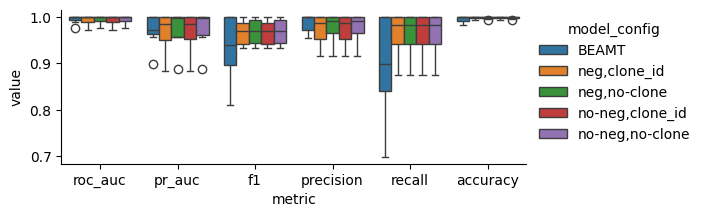

roc_auc 0.84375
pr_auc 0.84375
f1 0.15625
precision 0.625
recall 0.1875
accuracy 0.3125


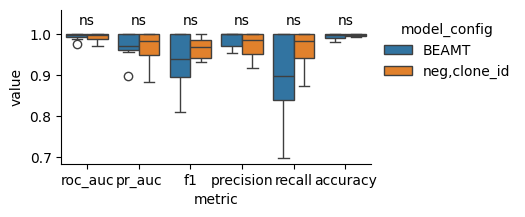

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

metrics_list = ['roc_auc', 'pr_auc', 'f1', 'precision', 'recall', 'accuracy']

# Show all model configurations or only neg,clone_id model
for show_all in [True, False]:
    results_melt = results_merged.sort_values(['setting', 'model_config']).melt( id_vars=['model_config', 'setting'], value_vars=metrics_list, var_name='metric', value_name='value' )
    if show_all:
        plt.figure(figsize=(6, 2))
        ax = sns.boxplot(data=results_melt, x='metric', y='value', hue='model_config', order=metrics_list)
        sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), frameon=False)
        sns.despine()
        plt.show()
        
    else:
        plt.figure(figsize=(4, 2))
        models_to_compare = ['BEAMT', 'neg,clone_id']
        df_filtered = results_melt[results_melt['model_config'].isin(models_to_compare)]
        
        ax = sns.boxplot(data=df_filtered, x='metric', y='value', hue='model_config', order=metrics_list)
        sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), frameon=False)
        
        y_max = df_filtered['value'].max()
        y_offset = (y_max - df_filtered['value'].min()) * 0.05
        
        for i, metric in enumerate(metrics_list):
            df_metric = results_merged.sort_values('setting')
            vec_1 = df_metric[df_metric['model_config'] == models_to_compare[0]][metric].values
            vec_2 = df_metric[df_metric['model_config'] == models_to_compare[1]][metric].values
            
            try:
                stat, p = wilcoxon(vec_1, vec_2)
                if p < 0.001: sig = '***'
                elif p < 0.01: sig = '**'
                elif p < 0.05: sig = '*'
                else: sig = 'ns'
            except:
                sig = 'ns'
            
            print(metric, p)
            ax.text(i, y_max + y_offset, sig, ha='center', va='bottom', )
        
        ax.set_ylim(top=y_max + (y_offset * 4))
        
        sns.despine()
        plt.show()

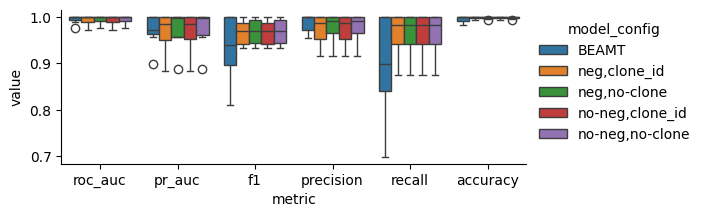

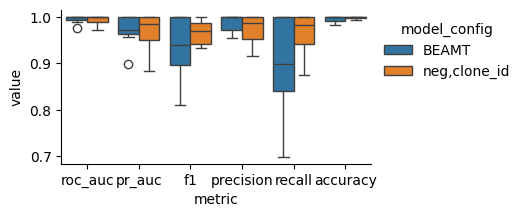

In [15]:
for show_all in [True, False]:
    results_melt = results_merged.sort_values(['setting', 'model_config']).melt(id_vars=['model_config'], value_vars=['roc_auc', 'pr_auc', 'f1', 'precision', 'recall', 'accuracy'], var_name='metric', value_name='value', )
    if show_all:
        plt.figure(figsize=(6, 2))
    else:
        results_melt = results_melt[results_melt['model_config'].isin(['BEAMT', 'neg,clone_id'])]
        plt.figure(figsize=(4, 2))
    
    ax = sns.boxplot(results_melt, x='metric', y='value', hue='model_config')
    sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), frameon=False)
    
    for container in ax.containers:
        try:
            ax.bar_label(container, fmt="%.3f", fontsize=10, label_type='edge', padding=5, rotation=90)
        except:
            pass
    
    # plt.xticks(rotation=10, ha='center')
    sns.despine()
    plt.show()

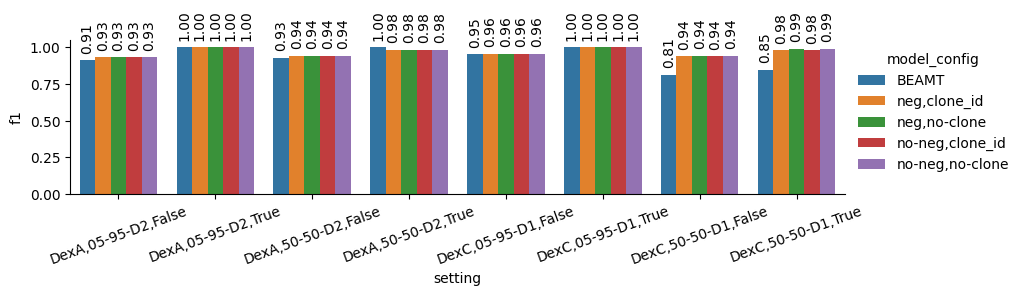

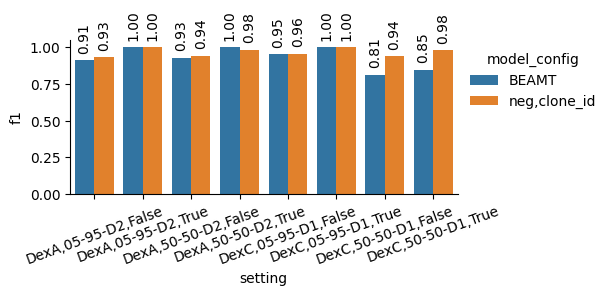

In [16]:
for show_all in [True, False]:
    results_sub = results_merged.copy()
    if show_all:
        plt.figure(figsize=(10, 2))
    else:
        plt.figure(figsize=(5, 2))
        results_sub = results_sub[results_sub['model_config'].isin(['BEAMT', 'neg,clone_id'])]


    ax = sns.barplot(results_sub.sort_values(['setting', 'model_config']), x='setting', y='f1', hue='model_config')
    sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), frameon=False)
    
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=10, label_type='edge', padding=5, rotation=90)
    
    plt.xticks(rotation=20, ha='center')
    sns.despine()
    plt.show()


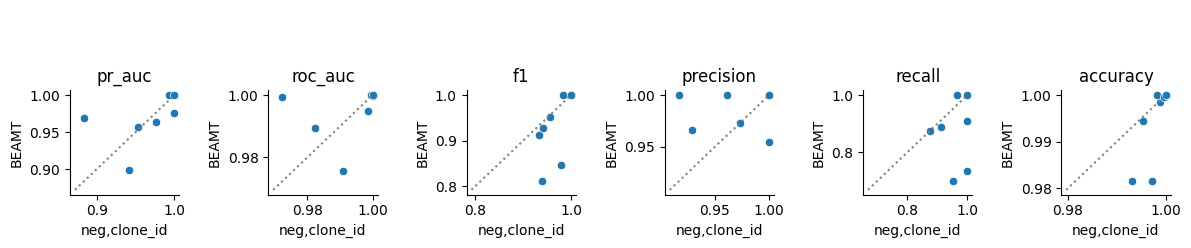

In [17]:
results_sub_plot = results_sub[results_sub['model_config'].isin(['BEAMT', 'neg,clone_id'])].copy()
metrics = ['pr_auc', 'roc_auc', 'f1', 'precision', 'recall', 'accuracy', ]
fig, axes = plt.subplots(1, len(metrics), figsize=(2 * len(metrics), 2))
legend_handles, legend_labels = None, None

for i, metric in enumerate(metrics):
    ax = axes[i]
    results_pivot = results_sub_plot.pivot( columns='model_config', values=metric, index=['setting', 'dex_key', 'sample', 'tcr_info_sequenced_only'] ).reset_index()
    results_pivot['dex'] = results_pivot['dex_key'].map(dex_map)
    results_pivot['dataset'] = results_pivot['dex'] + ',' + results_pivot['sample']
    sns.scatterplot( results_pivot, x='neg,clone_id', y='BEAMT', 
                    # hue='dataset', 
                    # hue='tcr_info_sequenced_only',
                    # style='tcr_info_sequenced_only', 
                    ax=ax, legend=(i == 0) )

    if i == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()
        if ax.legend_ is not None:
            ax.legend_.remove()

    sns.despine(ax=ax)
    min_value = results_sub_plot[metric].min()
    max_value = results_sub_plot[metric].max()
    diff = max_value - min_value
    ax.plot((min_value - diff * 0.1, 1), (min_value - diff * 0.1, 1), ls=':', c='grey')
    ax.set_title(metric)

fig.legend( legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=4, frameon=False )

plt.tight_layout()
plt.show()